<>:51: SyntaxWarning: invalid escape sequence '\s'
<>:51: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6617/972406838.py:51: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel('$\sqrt{2}x_1x_2$')


Hyperplane equation: 1.00*x + 0.00*y + -1.00*z + -0.00 = 0


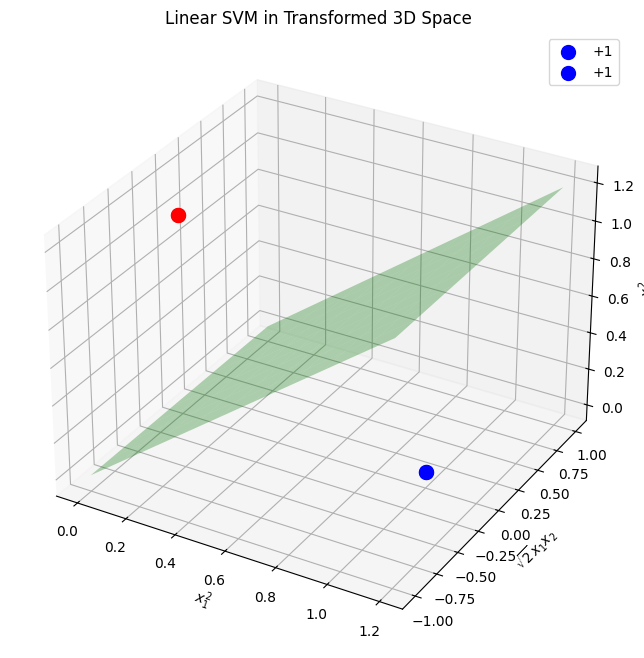

In [1]:
import numpy as np
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Original points and labels
X_original = np.array([
    [1, 0],   # A
    [-1, 0],  # B
    [0, 1],   # C
    [0, -1]   # D
    
])
# X_original = np.array([
 #   [1, 0],   # A
  #  [-1, 0],  # B
   # [0, 1],   # C
 #   [0, -1],   # D
 #   [2, 0],   # A
 #   [-2, 0],  # B
  #  [0, 2],   # C
   # [0, -2]   # D
#])
y = np.array([1, 1, -1, -1])  # Labels
#y = np.array([1, 1, -1, -1, 1, 1 , -1, -1])  # Labels
# Non-linear transformation to 3D: phi(x) = [x1^2, sqrt(2)x1x2, x2^2]
def phi(x):
    x1, x2 = x
    return [x1**2, np.sqrt(2)*x1*x2, x2**2]
# Apply transformation to all points
X_transformed = np.array([phi(x) for x in X_original])
# Train linear SVM in the transformed space
svm = SVC(kernel='linear', C=1e5)
svm.fit(X_transformed, y)
# Print separating hyperplane
w = svm.coef_[0]
b = svm.intercept_[0]
print(f"Hyperplane equation: {w[0]:.2f}*x + {w[1]:.2f}*y + {w[2]:.2f}*z + {b:.2f} = 0")
# Plotting the points and hyperplane
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
# Plot data points
for i, label in enumerate(y):
    color = 'blue' if label == 1 else 'red'
    ax.scatter(*X_transformed[i], c=color, s=100, label=f'{"+" if label == 1 else "-"}1' if i < 2 else "")
# Create a meshgrid for the hyperplane
xx, yy = np.meshgrid(np.linspace(0, 1.2, 10), np.linspace(-1, 1, 10))
zz = (-w[0]*xx - w[1]*yy - b) / w[2]
# Plot the separating plane
ax.plot_surface(xx, yy, zz, alpha=0.3, color='green')
ax.set_xlabel('$x_1^2$')
ax.set_ylabel('$\sqrt{2}x_1x_2$')
ax.set_zlabel('$x_2^2$')
ax.set_title('Linear SVM in Transformed 3D Space')
plt.legend()
plt.show()